# here is to plot the stuff

In [1]:
from metamers.eeg.ssvep_plotting import *
from metamers.behavioral.plotting import load_behavior_table

npz_root = "/home/zevaz/projects/metamers/eeg/ssveps"

df = load_metadata(npz_root)
beh = load_behavior_table()

print(beh.head())


    SubID     Red   Green  RunNumber  session  PartType       Date  \
0  MET001  2149.0   919.0          1        1         1  10_DEC_24   
1  MET001  1999.0  1038.0          2        1         1  10_DEC_24   
2  MET001  1489.0   777.0          3        1         1  10_DEC_24   
3  MET001  1745.0   997.0          4        1         1  10_DEC_24   
4  MET001  1835.0   875.0          5        1         1  10_DEC_24   

           FolderOrg  
0  S01_Beh_10_DEC_24  
1  S01_Beh_10_DEC_24  
2  S01_Beh_10_DEC_24  
3  S01_Beh_10_DEC_24  
4  S01_Beh_10_DEC_24  


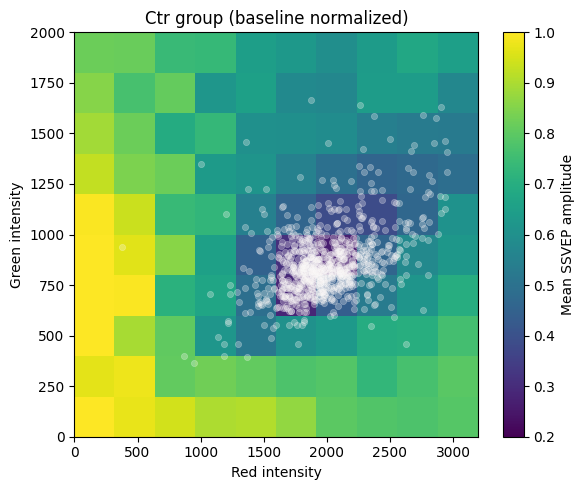

In [2]:
df_CTR = beh[beh["PartType"] == 1]
plot_group_mean_map_with_points(
    df=df,
    label="CTR",
    normalize=True,
    scatter_df=df_CTR,
    scatter_color="#FAF6F5",
    vmin = 0.2,
    vmax = 1,
    ymax = 2000
)

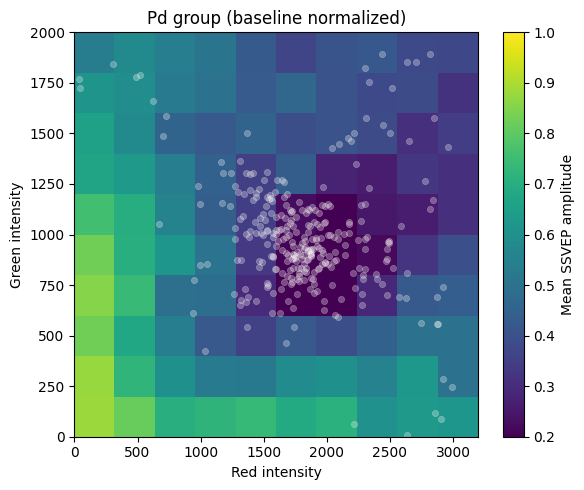

In [3]:
df_PD = beh[beh["PartType"] == 3]

plot_group_mean_map_with_points(
    df=df,
    label="PD",
    normalize=True,
    scatter_df=df_PD,
    scatter_color="#FAF6F5",
    vmin = 0.2,
    vmax = 1,
    ymax = 2000
)

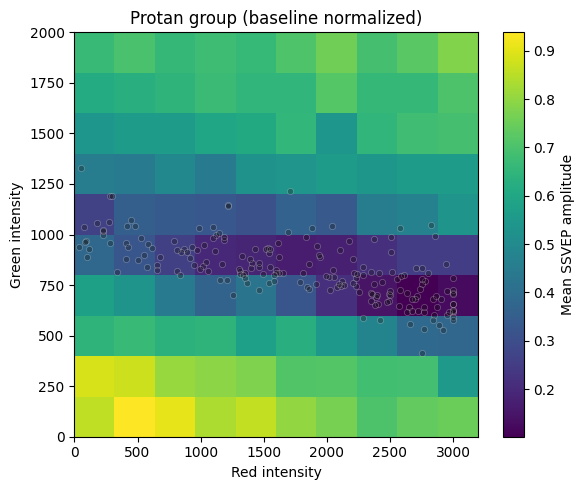

In [4]:
protans = ["MET016","MET017","MET028", "MET031", "MET036","MET045","MET046"]
df_Protan = beh[beh["SubID"].isin(protans)]

plot_group_mean_map_with_points(
    df=df,
    label="protan",
    normalize=True,
    scatter_df=df_Protan,
    scatter_color="#111111"
)

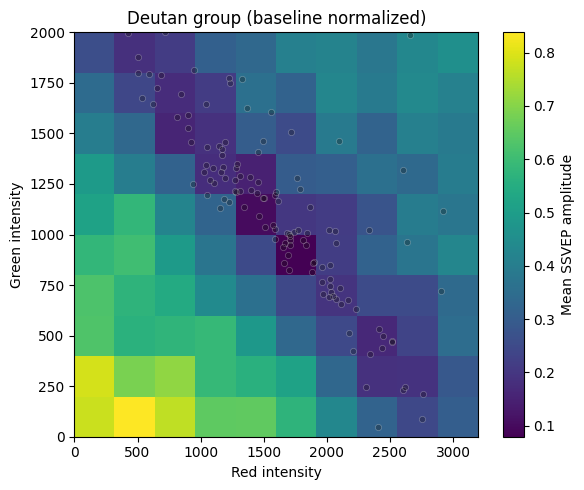

In [5]:
deutans = ["MET015", "MET029", "MET032", "MET033", "MET034", "MET043", "MET044"]
df_deutans = beh[beh["SubID"].isin(deutans)]

plot_group_mean_map_with_points(
    df=df,
    label="deutan",
    normalize=True,
    scatter_df=df_deutans,
    ymax = 2000,
    scatter_color="#111111"
)

In [6]:
sub2plot = "MET046"
session2plot = 1
npz_path = try_get_npz_path(df,sub2plot , session2plot)
data = load_ssvep_npz(npz_path)


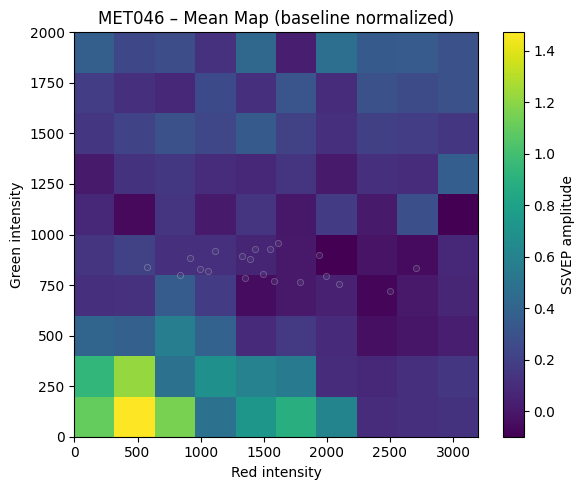

In [7]:
df_beh_part = beh[beh["SubID"] == sub2plot]

plot_participant_map_with_points(
    data,
    df_beh=df_beh_part,
    normalize=True,
    scatter_color="#534b7e"
)


In [ ]:
def load_participant_data(df_meta, beh, pid, session):
    """Return EEG NPZ data + behavioral df for a participant."""
    npz_path = df_meta.loc[
        (df_meta["participant_id"] == pid) & (df_meta["session"] == session),
        "npz_path"
    ].iloc[0]

    data = load_ssvep_npz(npz_path)
    df_beh_part = beh[beh["SubID"] == pid]

    return data, df_beh_part

import matplotlib.pyplot as plt
import numpy as np

def get_sessions_for_participant(df_meta, pid):
    """Return sorted list of sessions available for a participant."""
    return sorted(df_meta.loc[df_meta["participant_id"] == pid, "session"].unique())


def plot_participant_grid(
    df_meta,
    beh,
    pids,
    normalize=False,
    runs=None,
    cmap="viridis",
    scatter_color="#000000",
    scatter_size=30,
    cols=4
):
    """
    Plot a grid of participant SSVEP maps (all sessions) with behavioral overlays.
    """
    # Count total number of subplots needed
    total_plots = sum(len(get_sessions_for_participant(df_meta, pid)) for pid in pids)

    rows = int(np.ceil(total_plots / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()

    plot_idx = 0

    for pid in pids:
        sessions = get_sessions_for_participant(df_meta, pid)
        df_beh_part = beh[beh["SubID"] == pid]

        for session in sessions:
            ax = axes[plot_idx]

            # Load EEG + behavioral
            npz_path = df_meta.loc[
                (df_meta["participant_id"] == pid) &
                (df_meta["session"] == session),
                "npz_path"
            ].iloc[0]

            data = load_ssvep_npz(npz_path)

            # Compute mean map
            mean_map = get_participant_mean_map(data, normalize=normalize, runs=runs)

            # Axes
            red = data["red_array"]
            green = data["green_array"]

            # Plot heatmap
            ax.imshow(
                mean_map,
                origin="lower",
                cmap=cmap,
                extent=[red.min(), red.max(), green.min(), green.max()],
                aspect="auto"
            )

            # Overlay behavioral points
            if len(df_beh_part) > 0:
                ax.scatter(
                    df_beh_part["Red"],
                    df_beh_part["Green"],
                    c=scatter_color,
                    s=scatter_size,
                    edgecolor="white",
                    linewidth=0.5,
                    alpha=0.9
                )

            # Title
            ax.set_title(f"{pid} – Session {session}")
            ax.set_xlabel("Red")
            ax.set_ylabel("Green")

            plot_idx += 1

    # Hide unused axes
    for j in range(plot_idx, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()



In [ ]:
pids = df["participant_id"].unique()
plot_participant_grid(
    df,
    beh,
    pids,
    normalize=True,
    scatter_color="#534b7e"
)

In [ ]:
protans = ["MET016","MET017","MET028","MET031","MET036"]

plot_participant_grid(
    df,
    beh,
    protans,
    normalize=True,
    scatter_color="#ff0000"
)

In [ ]:
deutans = ["MET015", "MET029", "MET032", "MET033", "MET034"]


plot_participant_grid(
    df,
    beh,
    deutans,
    normalize=True,
    scatter_color="#17C234"
)

In [ ]:
pids_pd = df[df["group"] == "PD"]["participant_id"].unique()

plot_participant_grid(
    df,
    beh,
    pids_pd,
    normalize=True,
    scatter_color="#714b47"
)